# Temperature Calibration

Temperature calibration as descibred in the paper. 
The TT corner is measured data, while SS and FF are simulated.

The format of the saved values is a 3D NumPy array with dimensions:
`[corner, temperature, cprobe]`

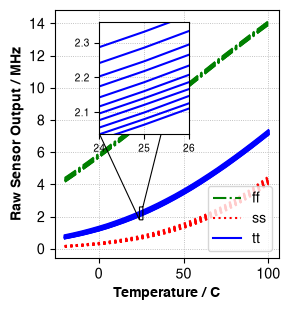

In [1]:
from matplotlib import pyplot as plt
from matplotlib.ticker import EngFormatter
import numpy as np

values = np.load("values.npy") # Reading the saved values
corners = ['ff', 'ss', 'tt']
cprobes = [1.00e-14, 2.10e-13, 4.10e-13, 6.10e-13, 8.10e-13, 1.01e-12, 1.21e-12, 1.41e-12, 1.61e-12, 1.81e-12, 2.01e-12]
temperatures = np.arange(-20, 101, 5)

fmt = EngFormatter(unit="")

plt.rcParams["font.family"] = "Helvetica"
plt.rcParams["axes.labelweight"] = "bold"

colors = ['g', 'r', 'b', 'k']
pattern = ['-.', 'dotted', '-', ':']

fig, ax = plt.subplots(figsize=(3.0, 3.2))
for ci, corner in enumerate(corners):
    for pi, cprobe in enumerate(cprobes):
        label = corner if pi == 0 else None
        ax.plot(temperatures, values[ci, :, pi] / 1e6, label=label, color=colors[ci], linestyle=pattern[ci])
ax.legend(loc="lower right")
ax.set_xlabel("Temperature / C")
ax.set_ylabel("Raw Sensor Output / MHz")
axins = ax.inset_axes([0.2,0.5,0.4,0.45])
for ci, corner in enumerate(corners):
    for pi, cprobe in enumerate(cprobes):
        label = corner if pi == 0 else None
        axins.plot(temperatures, values[ci, :, pi] / 1e6, label=label, color=colors[ci], linestyle=pattern[ci])
# Zoom region around 25 C
x1, x2 = 24, 26
axins.set_xlim(x1, x2)
# Automatically determine suitable y limits in this region
mask = (temperatures >= x1) & (temperatures <= x2)
zoom_values = []
i_tt_corner = corners.index("tt")   
for pi in range(len(cprobes)):
    zoom_values.extend(
        values[i_tt_corner, mask, pi] / 1e6
    )
zoom_values = np.asarray(zoom_values)
ymin = zoom_values.min()
ymax = zoom_values.max()
ypad = 0.10 * (ymax - ymin)
axins.set_ylim(ymin - ypad, ymax + ypad)
# Make inset ticks compact
axins.tick_params(axis="both", labelsize=7)
# Actual inset limits
inset_ymin = ymin - ypad
inset_ymax = ymax + ypad

axins.set_ylim(inset_ymin, inset_ymax)
axins.tick_params(axis="both", labelsize=7)
indicator_extension = 0.75 * (inset_ymax - inset_ymin)
indicator_ymin = inset_ymin - indicator_extension
indicator_ymax = inset_ymax + indicator_extension
ax.indicate_inset(
    bounds=[x1,indicator_ymin,x2 - x1,indicator_ymax - indicator_ymin],
    inset_ax=axins,
    edgecolor="black",
    alpha=1.0,
    linewidth=0.8
)
ax.grid(True,which="major",linestyle=":",linewidth=0.6,alpha=1.0)
axins.grid(True,which="major",linestyle=":",linewidth=0.6,alpha=1.0)
plt.tight_layout()

## Perform Calibration

The calibration have 3 steps:

1. Get to know which corner is this chip at.
2. Get offset by setting the reference capacitance to minimum
3. Get the gain by measuring another known reference capacitance (Now we have two) 

In [2]:
import numpy as np
# load values
values = np.load("values.npy")
# Force floating-point storage so sub-unit reference changes are preserved.
values_calibrated = np.array(values, dtype=float, copy=True)

colors = ['g', 'r', 'b', 'k']
corner_gains = [1.5, 20, 3]

i_norm = 5
a_norm = 3000 / len(cprobes) * i_norm
print(f"Normalization factor: {a_norm}")

for ci, corner in enumerate(corners):
    # Offset removal using the first cprobe as reference.
    values_calibrated[ci, :, :] = corner_gains[ci] * (values[ci, :, :] - values[ci, :, 0][:, np.newaxis])
    # Gain calibration using cprobes[i_norm].
    pp = values_calibrated[ci, :, 0] - values_calibrated[ci, :, i_norm]
    values_calibrated[ci, :, :] = a_norm * values_calibrated[ci, :, :] / pp[:, np.newaxis]

Normalization factor: 1363.6363636363637


ff, reference 0 range: 0.000000000 to 0.000000000; peak-to-peak = 0.000000000
ff, reference 5 range: -1363.636363636 to -1363.636363636; peak-to-peak = 0.000000000
ss, reference 0 range: 0.000000000 to 0.000000000; peak-to-peak = 0.000000000
ss, reference 5 range: -1363.636363636 to -1363.636363636; peak-to-peak = 0.000000000
tt, reference 0 range: 0.000000000 to 0.000000000; peak-to-peak = 0.000000000
tt, reference 5 range: -1363.636363636 to -1363.636363636; peak-to-peak = 0.000000000


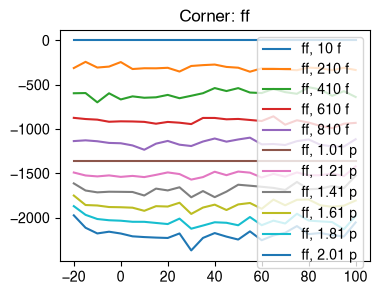

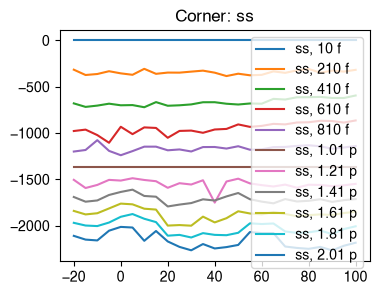

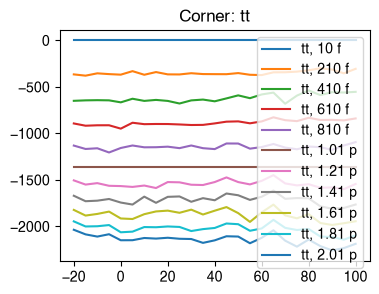

In [3]:
from matplotlib import pyplot as plt
from matplotlib.ticker import EngFormatter
fmt = EngFormatter(unit="")
for ci, corner in enumerate(corners):
    # Numerical verification that the reference arrays are not flat.
    print(
        f"{corner}, reference 0 range: "
        f"{np.min(values_calibrated[ci, :, 0]):.9f} to "
        f"{np.max(values_calibrated[ci, :, 0]):.9f}; "
        f"peak-to-peak = "
        f"{np.ptp(values_calibrated[ci, :, 0]):.9f}"
    )
    print(
        f"{corner}, reference {i_norm} range: "
        f"{np.min(values_calibrated[ci, :, i_norm]):.9f} to "
        f"{np.max(values_calibrated[ci, :, i_norm]):.9f}; "
        f"peak-to-peak = "
        f"{np.ptp(values_calibrated[ci, :, i_norm]):.9f}"
    )
    plt.figure(figsize=(4, 3))
    for capi, cprobe in enumerate(cprobes):
        plt.plot(
            temperatures,
            values_calibrated[ci, :, capi],
            label=f"{corner}, {fmt.format_data(cprobe)}",
        )
    plt.title(f"Corner: {corner}")
    plt.legend()
plt.show()

## 1/x2 Curve Correction

ff: points=(0,5,10), third=2.01 p, 0-1 p P-P=263.654 f, A=4.88173874e-12, B=-4.38961771e+03, C=1.05039636e-19
ss: points=(0,5,10), third=2.01 p, 0-1 p P-P=365.39 f, A=5.65769375e-12, B=-4.91470060e+03, C=1.57873711e-19
tt: points=(0,5,10), third=2.01 p, 0-1 p P-P=218.916 f, A=4.30560193e-12, B=-4.00057945e+03, C=7.45084721e-20


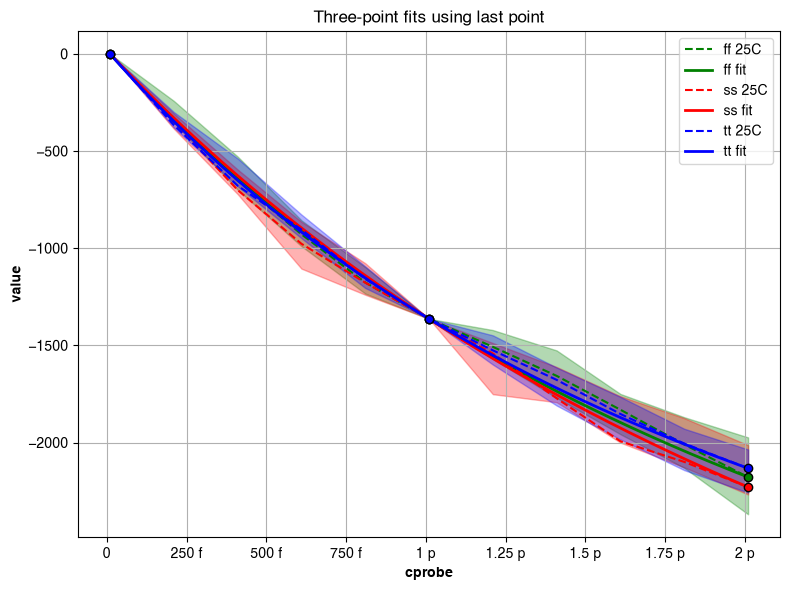

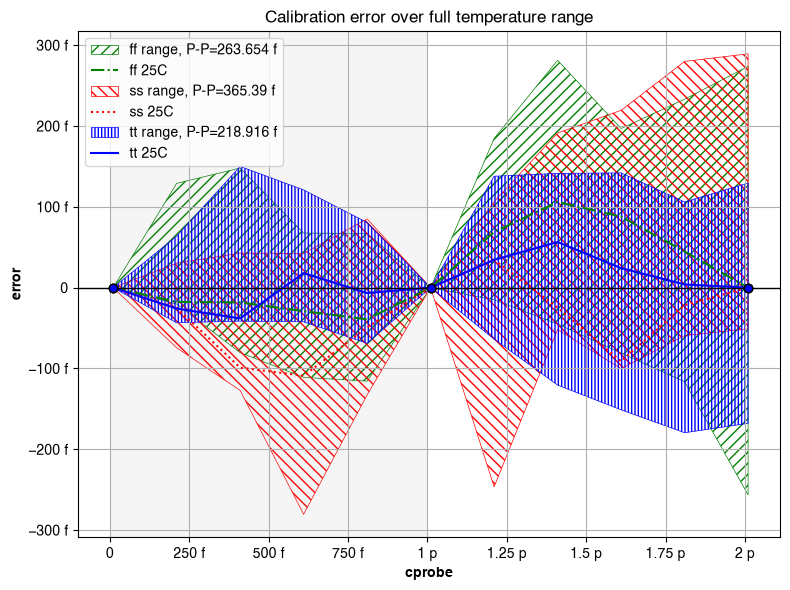

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from matplotlib.ticker import EngFormatter

fmt=EngFormatter(unit="")
T_FIT=25.0
CAL_RANGE_MIN=0.0
CAL_RANGE_MAX=1e-12
LOGA_MIN,LOGA_MAX,NGRID=-15.0,-9.0,1201

temps=np.asarray(temperatures,float)
xs=np.asarray(cprobes,float)
i_norm=int(i_norm)
ii=np.flatnonzero(np.isclose(temps,T_FIT))
if not ii.size: raise ValueError("25 C is not present in temperatures.")
i25=int(ii[0])
if xs.ndim!=1: raise ValueError("cprobes must be one-dimensional.")
if not 0<=i_norm<len(xs) or i_norm==0: raise ValueError("i_norm must be valid and nonzero.")
i_fit=len(xs)-1
if i_fit==i_norm: raise ValueError("i_norm cannot be the last point.")

cal_mask=np.isfinite(xs)&(xs>=CAL_RANGE_MIN)&(xs<=CAL_RANGE_MAX)
err_scale=xs[-1]/1500.0

def model(x,A,B,C): return C/(x+A)**2+B

def solve_cb(A,x,y):
    z=1/(x+A)**2; dz=z-z.mean(); den=np.sum(dz*dz)
    if den<=0 or not np.isfinite(den): return np.nan,np.nan
    C=np.sum(dz*(y-y.mean()))/den
    return C,y.mean()-C*z.mean()

def cost(logA,x,y):
    A=10**logA; C,B=solve_cb(A,x,y)
    if not np.isfinite(C) or not np.isfinite(B) or C<=0: return np.inf
    return float(np.sum((y-model(x,A,B,C))**2))

def fit3(x,y):
    g=np.linspace(LOGA_MIN,LOGA_MAX,NGRID); gc=np.array([cost(v,x,y) for v in g]); j=int(np.argmin(gc))
    if not np.isfinite(gc[j]): raise RuntimeError("No valid positive-C fit.")
    lo,hi=g[max(j-1,0)],g[min(j+1,len(g)-1)]; logA=float(g[j])
    if hi>lo:
        r=minimize_scalar(lambda v:cost(v,x,y),bounds=(lo,hi),method="bounded",options={"xatol":1e-12,"maxiter":10000})
        if r.success and np.isfinite(r.fun) and r.fun<gc[j]: logA=float(r.x)
    A=10**logA; C,B=solve_cb(A,x,y)
    return A,B,C

fits=[]
for ci,corner in enumerate(corners):
    y=np.asarray(values_calibrated[ci,i25,:],float)
    valid=np.isfinite(xs)&np.isfinite(y)
    score=valid&cal_mask
    idx=np.array([0,i_norm,i_fit])
    if not np.all(valid[idx]): raise ValueError(f"{corner}: fit points are not finite.")
    if np.unique(xs[idx]).size!=3: raise ValueError(f"{corner}: fit points must have unique x values.")

    A,B,C=fit3(xs[idx],y[idx])
    baseline=model(xs,A,B,C)
    tmax=np.nanmax(values_calibrated[ci,:,:],axis=0)
    tmin=np.nanmin(values_calibrated[ci,:,:],axis=0)
    emax=(tmax[score]-baseline[score])*err_scale
    emin=(tmin[score]-baseline[score])*err_scale
    e=np.r_[emin,emax]
    f={"third":i_fit,"idx":idx,"A":A,"B":B,"C":C,"p2p":float(np.max(emax)-np.min(emin)),"maxabs":float(np.max(np.abs(e))),"rmse":float(np.sqrt(np.mean(e**2)))}
    fits.append(f)

    print(f"{corner}: points=(0,{i_norm},{i_fit}), third={fmt.format_data(xs[i_fit])}, {fmt.format_data(CAL_RANGE_MIN)}-{fmt.format_data(CAL_RANGE_MAX)} P-P={fmt.format_data(f['p2p'])}, A={A:.8e}, B={B:.8e}, C={C:.8e}")


xd=np.linspace(np.nanmin(xs),np.nanmax(xs),1000)
plt.figure(figsize=(8,6))
for ci,corner in enumerate(corners):
    f=fits[ci]
    tmax=np.nanmax(values_calibrated[ci,:,:],axis=0)
    tmin=np.nanmin(values_calibrated[ci,:,:],axis=0)
    y25=np.asarray(values_calibrated[ci,i25,:],float)
    m=np.isfinite(xs)&np.isfinite(tmin)&np.isfinite(tmax)&np.isfinite(y25)
    plt.fill_between(xs[m],tmin[m],tmax[m],color=colors[ci],alpha=.3)
    plt.plot(xs[m],y25[m],"--",color=colors[ci],label=f"{corner} 25C")
    plt.plot(xd,model(xd,f["A"],f["B"],f["C"]),color=colors[ci],lw=2,label=f"{corner} fit")
    plt.scatter(xs[f["idx"]],y25[f["idx"]],color=colors[ci],edgecolors="black",zorder=5)

plt.title("Three-point fits using last point")
plt.xlabel("cprobe")
plt.ylabel("value")
plt.gca().xaxis.set_major_formatter(fmt)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
hatches=["///","\\\\\\","|||||"]
pattern=['-.','dotted','-',':']

for ci,corner in enumerate(corners):
    f=fits[ci]
    baseline=model(xs,f["A"],f["B"],f["C"])*err_scale
    tmax=np.nanmax(values_calibrated[ci,:,:],axis=0)*err_scale
    tmin=np.nanmin(values_calibrated[ci,:,:],axis=0)*err_scale
    y25=np.asarray(values_calibrated[ci,i25,:],float)*err_scale
    error=y25-baseline
    m=np.isfinite(xs)&np.isfinite(error)&np.isfinite(tmin)&np.isfinite(tmax)&np.isfinite(baseline)

    plt.fill_between(xs[m],tmin[m]-baseline[m],tmax[m]-baseline[m],facecolor="none",edgecolor=colors[ci],hatch=hatches[ci],linewidth=.5,label=f"{corner} range, P-P={fmt.format_data(f['p2p'])}")
    plt.plot(xs[m],error[m],linestyle=pattern[ci],color=colors[ci],label=f"{corner} 25C")
    plt.scatter(xs[f["idx"]],error[f["idx"]],color=colors[ci],edgecolors="black",zorder=5)

plt.axhline(0,color="black",lw=1)
plt.axvspan(CAL_RANGE_MIN,CAL_RANGE_MAX,color="gray",alpha=.08)
plt.title("Calibration error over full temperature range")
plt.xlabel("cprobe")
plt.ylabel("error")
plt.gca().xaxis.set_major_formatter(fmt)
plt.gca().yaxis.set_major_formatter(fmt)
plt.grid(True)
plt.legend()
plt.tight_layout()
# plt.show()